In [1]:
import sys
from pathlib import Path

# Adds 'dir1' (the parent directory) to Jupyter's path
sys.path.append(str(Path.cwd().parent))

import tps_pinn 


In [2]:
from scipy.stats import qmc
from scipy.io import loadmat
import numpy as np
import time
import matplotlib.pyplot as plt
import torch
torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# Por enunciado
# Puntos de colocación y de datos
N_PDE = 10000
N_BC = 1000
N_DATA = 10
# Pesos de ponderacion
LAMBDA_BC = 10
LAMBDA_PDE = 100
# Límites
X_LIM = (0, 1)
Y_LIM = (0, 1)
# Epocas de entrenamiento
EPOCHS = 50000


In [4]:
X_bc_u, y_bc_u, X_bc_p, y_bc_p = tps_pinn.set_X_bc(N_BC)

In [5]:
# Importo data de ground truth
pressure_data = loadmat('../data/pressure.mat')
velocity_data = loadmat('../data/velocity.mat')
X_data_all = torch.tensor(np.hstack((pressure_data['x'].transpose(), pressure_data['y'].transpose())), dtype=torch.float32)
y_data_all = torch.tensor(np.hstack((pressure_data['p'].transpose(), velocity_data['u'].transpose(),velocity_data['v'].transpose())), dtype=torch.float32)


In [6]:
# Hiperparámetros
USE_DATA = False
HIDDEN_LAYERS = 3
HIDDEN_UNITS = 32
ACTIVATION = torch.nn.Tanh()

In [7]:
model_params = {
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_units': HIDDEN_UNITS,
    'activation': ACTIVATION,
    'Re': 100,
    'device': device
}
tags = ['PDE', 'BC_VEL', 'BC_P']
dataset_bc = [
    torch.utils.data.TensorDataset(X_bc_u, y_bc_u),                 # BC velocity
    torch.utils.data.TensorDataset(X_bc_p, y_bc_p),                 # BC pressure
]


In [8]:
# Defino hiperparámetros para RAR-D
hyperparams_rard = {
    "base": {"K": 1, "C": 1},
    "alta explotacion": {"K": 2, "C": 0},
    "alta exploracion": {"K": 1, "C": 3},
}
# Parametros para muestreo inical por LHS
N_PDE = 5000
N_BC = 1000 # Mantengo como en caso baseline
EPOCHS_LHS = 10000
# Parametros para rondas de rard
ROUNDS = 4
EPOCHS_ROUND = 10000
WINNERS = 1000
CANDIDATES = 20000

In [9]:
"""
Variación BASE de RAR-D
"""
hyperparams = hyperparams_rard['base']
base_rard_pinn = tps_pinn.PINN(model_params).to(device)

# Entrenamiento
start_time = time.perf_counter()
pinn, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history, l2_error, opt = tps_pinn.train_pinn_rard(
    base_rard_pinn, dataset_bc,
    lhs_params = {
        "epochs" : EPOCHS_LHS, 
        "n_pde" : N_PDE
    }, rounds_params = {
        "rounds": ROUNDS,
        "epochs": EPOCHS_ROUND,
        "candidates": CANDIDATES,
        "winners": WINNERS,
        "k": hyperparams["K"], "c": hyperparams["C"]
    }, device = device, lambdas = {
        "pde": LAMBDA_PDE,
        "bc_u": LAMBDA_BC, 
        "bc_p": LAMBDA_BC, 
    }, X_data_all=X_data_all, y_data_all=y_data_all
)
base_rard_time = time.perf_counter() - start_time
print(f"Tiempo de entrenamiento RAR-D (base): {base_rard_time:.1f}s")

Comenzando entrenamiento del modelo...


/home/jiteich/repos/ceia/pinn_ceia/TPs/tps_pinn.py:112: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()


Epoch 0, PDE Loss: 6.650930, BC vel. Loss: 0.430096, BC pres. Loss: 0.000000, DATA Loss: N/A
Epoch 10, PDE Loss: 6.523152, BC vel. Loss: 0.428599, BC pres. Loss: 0.000011, DATA Loss: N/A
Epoch 20, PDE Loss: 5.807639, BC vel. Loss: 0.414041, BC pres. Loss: 0.000175, DATA Loss: N/A
Epoch 30, PDE Loss: 5.102171, BC vel. Loss: 0.398151, BC pres. Loss: 0.000426, DATA Loss: N/A
Epoch 40, PDE Loss: 4.658169, BC vel. Loss: 0.387171, BC pres. Loss: 0.000579, DATA Loss: N/A
Epoch 50, PDE Loss: 4.307042, BC vel. Loss: 0.377408, BC pres. Loss: 0.000659, DATA Loss: N/A
Epoch 60, PDE Loss: 3.994384, BC vel. Loss: 0.367597, BC pres. Loss: 0.000662, DATA Loss: N/A
Epoch 70, PDE Loss: 3.695480, BC vel. Loss: 0.357478, BC pres. Loss: 0.000580, DATA Loss: N/A
Epoch 80, PDE Loss: 3.406745, BC vel. Loss: 0.348160, BC pres. Loss: 0.000430, DATA Loss: N/A
Epoch 90, PDE Loss: 3.142213, BC vel. Loss: 0.340887, BC pres. Loss: 0.000259, DATA Loss: N/A
Epoch 100, PDE Loss: 2.896073, BC vel. Loss: 0.335990, BC pre

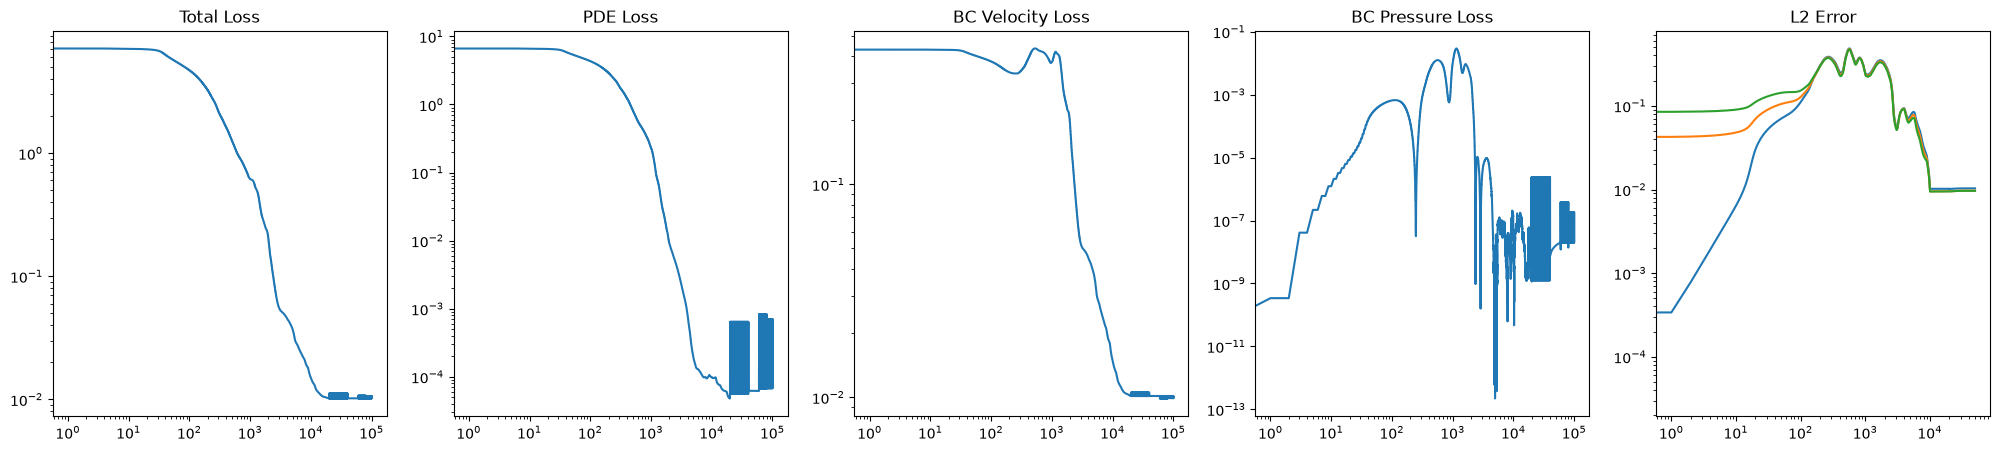

RAR-D (base) Error L-2 p: 0.0103
RAR-D (base) Error L-2 u: 0.0097
RAR-D (base) Error L-2 v: 0.0096


In [10]:
if USE_DATA:
    loss_history = [pde + bc_vel + bc_p + data for pde, bc_vel, bc_p, data in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history)]
else:
    loss_history = [pde + bc_vel + bc_p for pde, bc_vel, bc_p in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history)]

tps_pinn.plot_hist(loss_history, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, l2_error, use_data=USE_DATA, data_loss_history = data_loss_history)
print(f"RAR-D (base) Error L-2 p: {l2_error[0][-1]:.4f}")
print(f"RAR-D (base) Error L-2 u: {l2_error[1][-1]:.4f}")
print(f"RAR-D (base) Error L-2 v: {l2_error[2][-1]:.4f}")

In [11]:
"""
Variación Explotación de RAR-D
"""
hyperparams = hyperparams_rard['alta explotacion']
explotation_rard_pinn = tps_pinn.PINN(model_params).to(device)

# Entrenamiento
start_time = time.perf_counter()
explotation_rard_pinn, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history, l2_error, opt = tps_pinn.train_pinn_rard(
    explotation_rard_pinn, dataset_bc,
    lhs_params = {
        "epochs" : EPOCHS_LHS, 
        "n_pde" : N_PDE
    }, rounds_params = {
        "rounds": ROUNDS,
        "epochs": EPOCHS_ROUND,
        "candidates": CANDIDATES,
        "winners": WINNERS,
        "k": hyperparams["K"], "c": hyperparams["C"]
    }, device = device, lambdas = {
        "pde": LAMBDA_PDE,
        "bc_u": LAMBDA_BC, 
        "bc_p": LAMBDA_BC, 
    }, X_data_all=X_data_all, y_data_all=y_data_all
)
explotation_rard_time = time.perf_counter() - start_time
print(f"Tiempo de entrenamiento RAR-D (explotation): {explotation_rard_time:.1f}s")


Comenzando entrenamiento del modelo...
Epoch 0, PDE Loss: 7.604818, BC vel. Loss: 0.155584, BC pres. Loss: 0.000000, DATA Loss: N/A
Epoch 10, PDE Loss: 5.459462, BC vel. Loss: 0.216828, BC pres. Loss: 0.000201, DATA Loss: N/A
Epoch 20, PDE Loss: 5.076269, BC vel. Loss: 0.234527, BC pres. Loss: 0.000197, DATA Loss: N/A
Epoch 30, PDE Loss: 4.617079, BC vel. Loss: 0.258468, BC pres. Loss: 0.000083, DATA Loss: N/A
Epoch 40, PDE Loss: 4.119100, BC vel. Loss: 0.286463, BC pres. Loss: 0.000027, DATA Loss: N/A
Epoch 50, PDE Loss: 3.678592, BC vel. Loss: 0.312863, BC pres. Loss: 0.000681, DATA Loss: N/A
Epoch 60, PDE Loss: 3.317442, BC vel. Loss: 0.334641, BC pres. Loss: 0.002554, DATA Loss: N/A
Epoch 70, PDE Loss: 2.961368, BC vel. Loss: 0.352975, BC pres. Loss: 0.007065, DATA Loss: N/A
Epoch 80, PDE Loss: 2.638397, BC vel. Loss: 0.366587, BC pres. Loss: 0.014938, DATA Loss: N/A
Epoch 90, PDE Loss: 2.372509, BC vel. Loss: 0.375102, BC pres. Loss: 0.025355, DATA Loss: N/A
Epoch 100, PDE Loss: 2

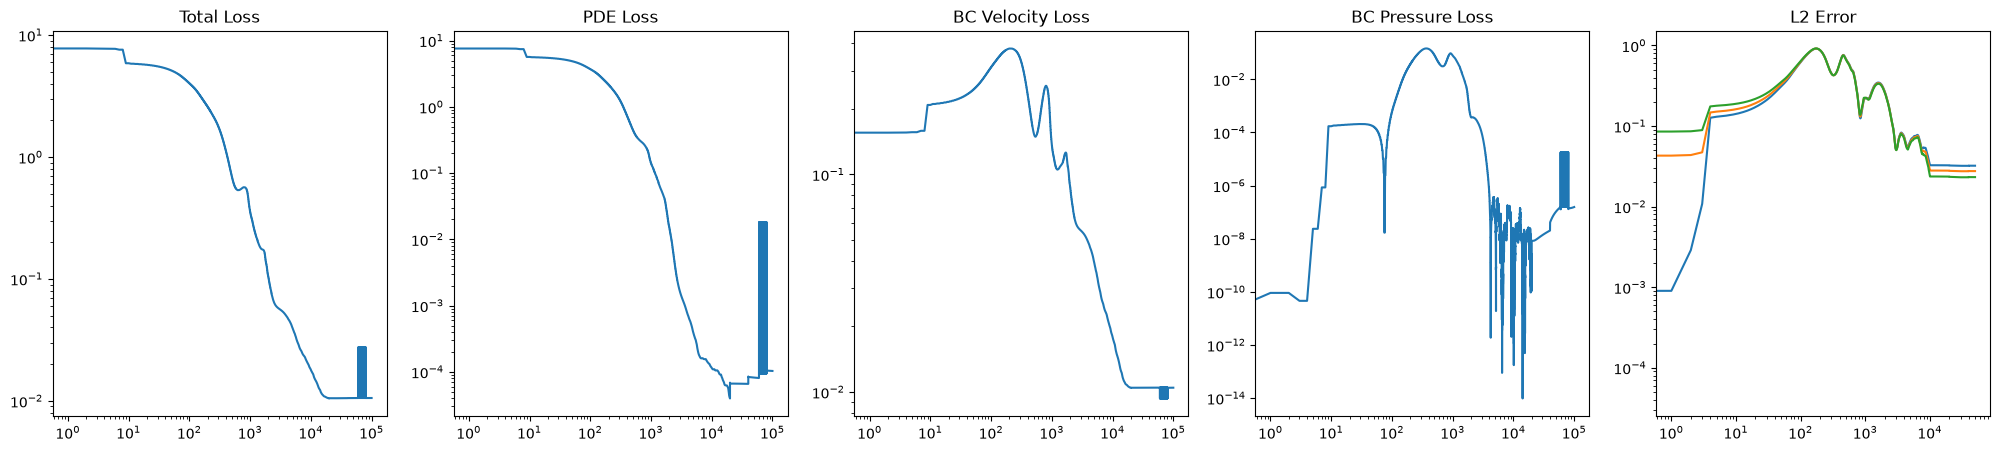

RAR-D (base) Error L-2 p: 0.0322
RAR-D (base) Error L-2 u: 0.0276
RAR-D (base) Error L-2 v: 0.0232


In [12]:
if USE_DATA:
    loss_history = [pde + bc_vel + bc_p + data for pde, bc_vel, bc_p, data in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history)]
else:
    loss_history = [pde + bc_vel + bc_p for pde, bc_vel, bc_p in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history)]

tps_pinn.plot_hist(loss_history, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, l2_error, use_data=USE_DATA, data_loss_history = data_loss_history)
print(f"RAR-D (base) Error L-2 p: {l2_error[0][-1]:.4f}")
print(f"RAR-D (base) Error L-2 u: {l2_error[1][-1]:.4f}")
print(f"RAR-D (base) Error L-2 v: {l2_error[2][-1]:.4f}")

In [9]:
"""
Variación Exploración de RAR-D
"""
hyperparams = hyperparams_rard['alta exploracion']
exploration_rard_pinn = tps_pinn.PINN(model_params).to(device)

# Entrenamiento
start_time = time.perf_counter()
exploration_rard_pinn, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history, l2_error, opt = tps_pinn.train_pinn_rard(
    exploration_rard_pinn, dataset_bc,
    lhs_params = {
        "epochs" : EPOCHS_LHS, 
        "n_pde" : N_PDE
    }, rounds_params = {
        "rounds": ROUNDS,
        "epochs": EPOCHS_ROUND,
        "candidates": CANDIDATES,
        "winners": WINNERS,
        "k": hyperparams["K"], "c": hyperparams["C"]
    }, device = device, lambdas = {
        "pde": LAMBDA_PDE,
        "bc_u": LAMBDA_BC, 
        "bc_p": LAMBDA_BC, 
    }, X_data_all=X_data_all, y_data_all=y_data_all
)
exploration_rard_time = time.perf_counter() - start_time
print(f"Tiempo de entrenamiento RAR-D (exploration): {exploration_rard_time:.1f}s")


Comenzando entrenamiento del modelo...


/home/jiteich/repos/ceia/pinn_ceia/TPs/tps_pinn.py:112: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()


Epoch 0, PDE Loss: 6.670561, BC vel. Loss: 0.430096, BC pres. Loss: 0.000000, DATA Loss: N/A
Epoch 10, PDE Loss: 6.542095, BC vel. Loss: 0.428679, BC pres. Loss: 0.000011, DATA Loss: N/A
Epoch 20, PDE Loss: 5.844126, BC vel. Loss: 0.416133, BC pres. Loss: 0.000188, DATA Loss: N/A
Epoch 30, PDE Loss: 5.130770, BC vel. Loss: 0.401570, BC pres. Loss: 0.000490, DATA Loss: N/A
Epoch 40, PDE Loss: 4.683021, BC vel. Loss: 0.391250, BC pres. Loss: 0.000691, DATA Loss: N/A
Epoch 50, PDE Loss: 4.328684, BC vel. Loss: 0.381795, BC pres. Loss: 0.000817, DATA Loss: N/A
Epoch 60, PDE Loss: 4.011615, BC vel. Loss: 0.371965, BC pres. Loss: 0.000858, DATA Loss: N/A
Epoch 70, PDE Loss: 3.707043, BC vel. Loss: 0.361504, BC pres. Loss: 0.000797, DATA Loss: N/A
Epoch 80, PDE Loss: 3.414783, BC vel. Loss: 0.351599, BC pres. Loss: 0.000645, DATA Loss: N/A
Epoch 90, PDE Loss: 3.150833, BC vel. Loss: 0.343560, BC pres. Loss: 0.000449, DATA Loss: N/A
Epoch 100, PDE Loss: 2.912577, BC vel. Loss: 0.337809, BC pre

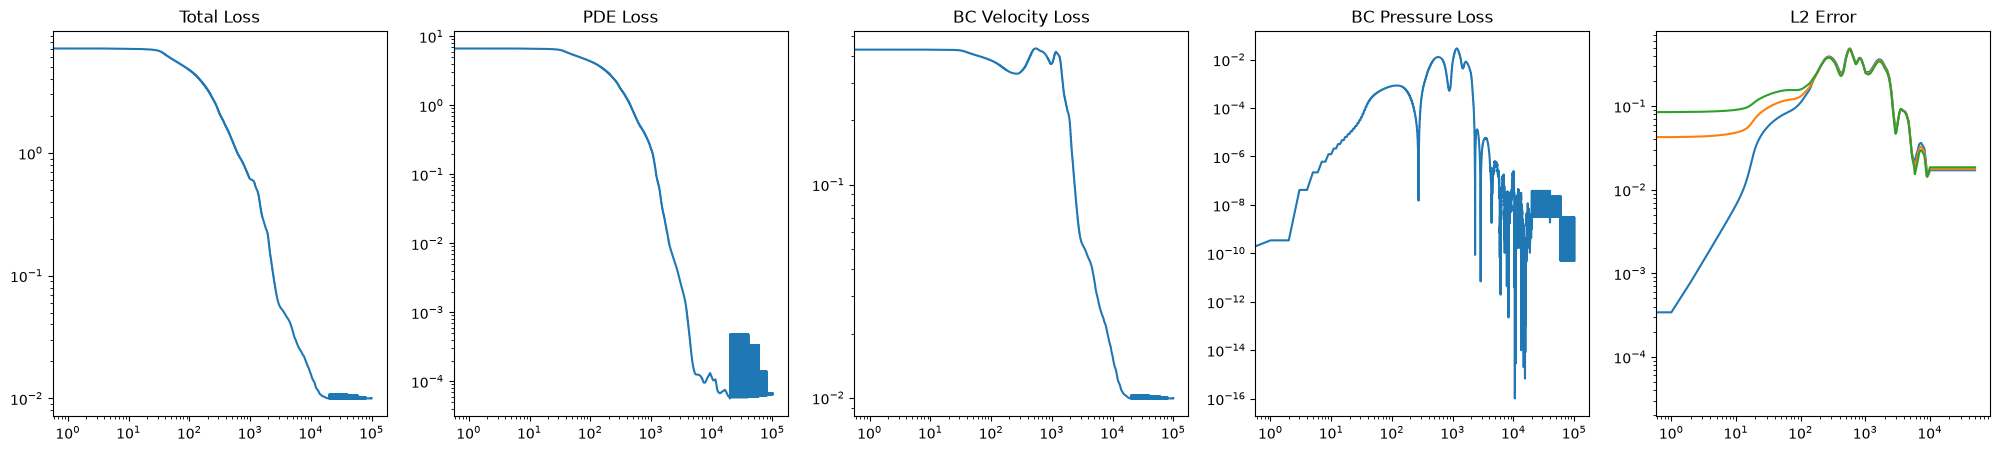

RAR-D (base) Error L-2 p: 0.0171
RAR-D (base) Error L-2 u: 0.0176
RAR-D (base) Error L-2 v: 0.0185


In [10]:
if USE_DATA:
    loss_history = [pde + bc_vel + bc_p + data for pde, bc_vel, bc_p, data in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history)]
else:
    loss_history = [pde + bc_vel + bc_p for pde, bc_vel, bc_p in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history)]

tps_pinn.plot_hist(loss_history, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, l2_error, use_data=USE_DATA, data_loss_history = data_loss_history)
print(f"RAR-D (base) Error L-2 p: {l2_error[0][-1]:.4f}")
print(f"RAR-D (base) Error L-2 u: {l2_error[1][-1]:.4f}")
print(f"RAR-D (base) Error L-2 v: {l2_error[2][-1]:.4f}")